In [23]:
#getting python plotting functions, problems when I copy python folder into env modules folder
import sys
sys.path.insert(0, "/Users/ayman/Documents/GitHub/riesling/python")

import riesling as rlp

import sys
from pathlib import Path
import os

riesling_bin = Path.home() / "Documents" / "github" / "riesling" / "build" / "cxx" / "riesling"
os.environ["PATH"] += os.pathsep + str(riesling_bin)

- no `nex` file
- changed to `snr`

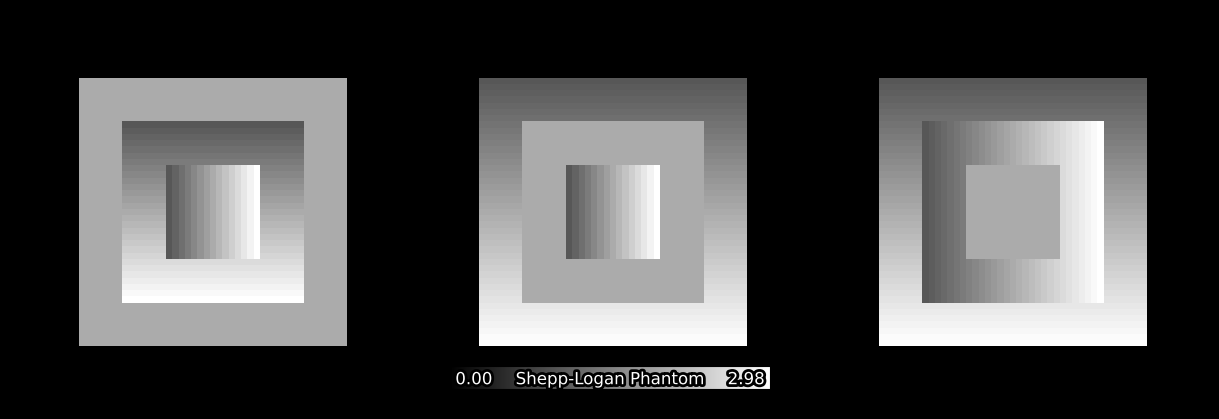

In [4]:
prefix='tut'
matrix=64
voxsz=3
spokes=8192
!riesling phantom {prefix}-phantom.h5 --matrix={matrix} --vox-size={voxsz} --snr=0.5 --gradcubes --size=64 --spokes={spokes}
rlp.plot.planes(f'{prefix}-phantom.h5', title='Shepp-Logan Phantom')

In [22]:
#!riesling phantom

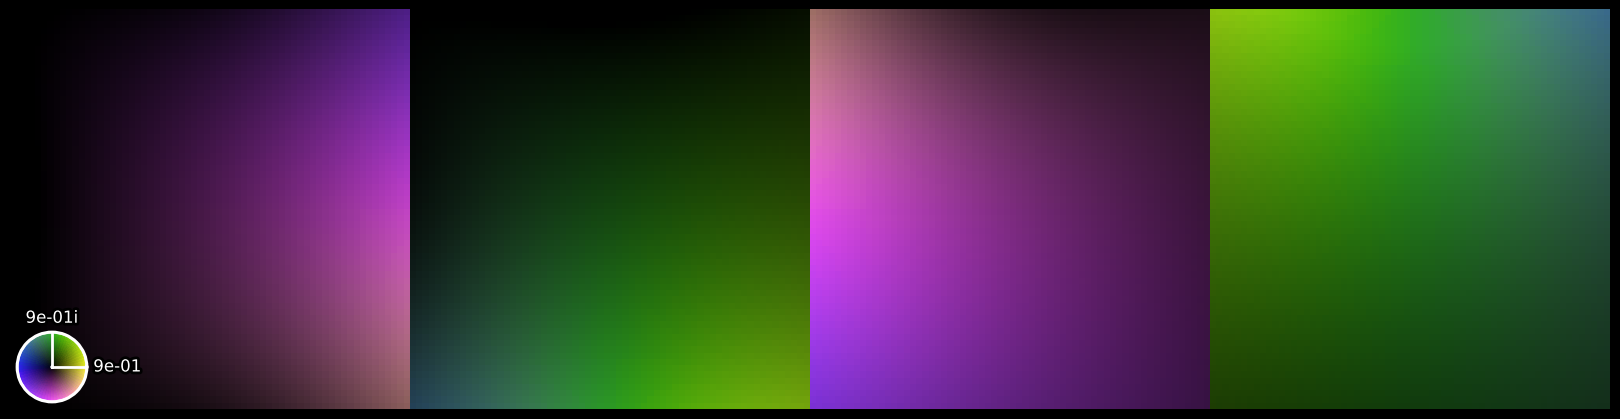

In [5]:
channels=4
!riesling sense-sim {prefix}-sim-sense.h5 --matrix={matrix} --vox-size={voxsz} --channels={channels}
rlp.plot.sense(f'{prefix}-sim-sense.h5')

- `gradcubes` not recognised

In [ ]:
!riesling op-sense --help

  riesling op-sense {OPTIONS} [FILE] [FILE] [FILE]

    Channel combine with SENSE

  OPTIONS:

      FILE                              Input HD5 file
      FILE                              SENSE maps HD5 file
      FILE                              Output HD5 file
      -f, --fwd                         Apply forward operation
      -e, --eig                         Estimate eigenvalue & vector
      -d[D], --dset=[D]                 Dataset name (image/channels)
      GLOBAL OPTIONS
        -h, --help                        Show this help message
        -v[V], --verbosity=[V]            Log level 0-3
        --debug=[F]                       Write debug images to file
        --nthreads=[N]                    Limit number of threads
        --deflate=[D]                     Set deflate level (0=none)
      "--" can be used to terminate flag options and force all following
      arguments to be treated as positional options




In [6]:
### NOTE: channels appears to be in the wrong place to run here <<-- had to swap
!riesling op-sense --fwd {prefix}-phantom.h5 {prefix}-sim-sense.h5 {prefix}-channels.h5

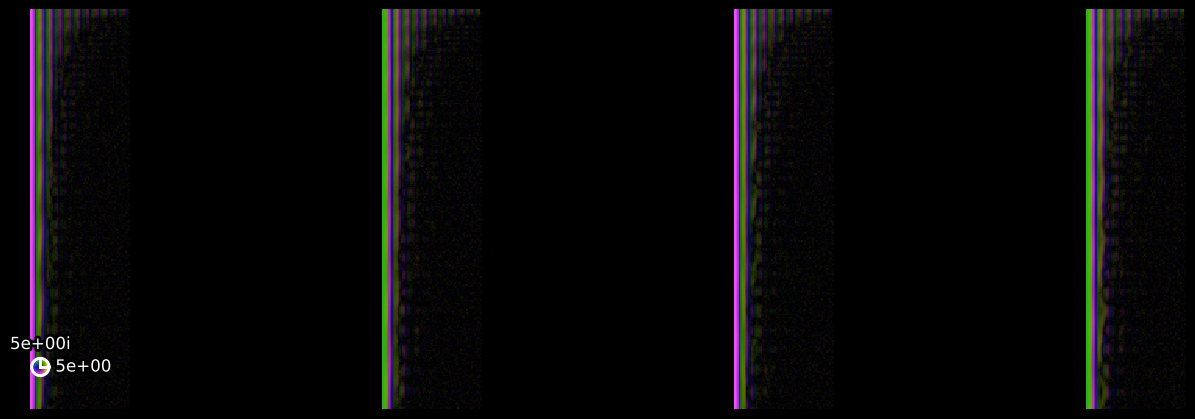

In [7]:
!riesling op-nufft --fwd {prefix}-channels.h5 {prefix}-noiseless.h5
!riesling noisify {prefix}-noiseless.h5 {prefix}-kspace.h5 --std=0.2
rlp.plot.noncart(f'{prefix}-kspace.h5', trace=slice(0,256))

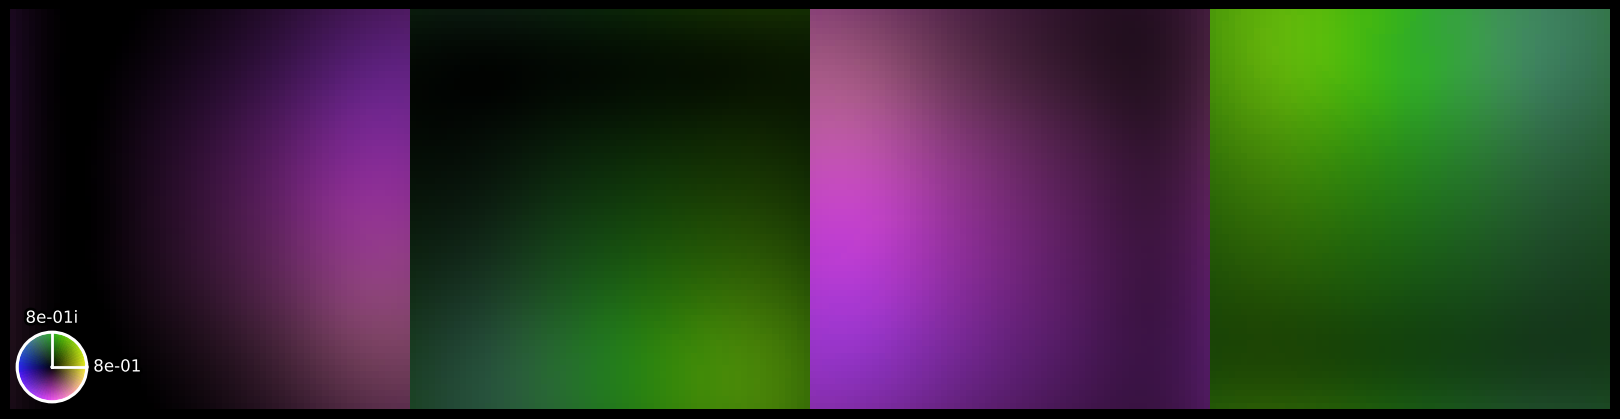

In [ ]:
!riesling sense-calib {prefix}-kspace.h5 temp.h5
!riesling sense-maps temp.h5 {prefix}-kspace.h5 temp2.h5
rlp.plot.sense(f'temp2.h5')


In [39]:
!riesling precon "{prefix}-kspace.h5" "{prefix}-precon.h5"

In [43]:
!riesling recon-lsq

  riesling recon-lsq {OPTIONS} [FILE] [FILE]

    Least-squares (iterative) recon

  OPTIONS:

      FILE                              Input HD5 file
      FILE                              Output HD5 file
      -d[D], --dset=[D]                 Dataset name
      -b[B], --basis=[B]                Read basis from file
      -m[M], --matrix=[M]               Override matrix size
      -r, --resid                       Output k-space residual
      -f[FOV], --fov=[FOV]              Grid FoV in mm (x,y,z)
      -o[O], --osamp=[O]                Grid oversampling factor (1.3)
      --tophat                          Use a top hat (NN) kernel
      --kwidth=[W]                      ExpSemi kernel width
      --decant                          Direct Virtual Coil (SENSE via
                                        convolution)
      -l, --lowmem                      Low memory mode
      -p[P], --precon=[P]               Preconditioner
                                        (none/single/multi/

In [57]:
!riesling recon-lsq --precon="{prefix}-precon.h5" --precon-p=1 {prefix}-kspace.h5 {prefix}-lsq.h5 -v2

[00:20:20] [recon-lsq] Welcome to RIESLING
[00:20:20] [HD5   ] Opened tut-kspace.h5 for reading id 72057594037927936
[00:20:20] [Traj  ] 3D Samples 64 Traces 8192 Matrix [64, 64, 64] FOV [192.00, 192.00, 192.00]
[00:20:20] [SENSE ] Self-Calibration
[00:20:20] [Traj  ] Retaining samples 0-63 traces 0-8191
[00:20:20] [Traj  ] Downsample [6, 6, 6] voxel-size, [32, 32, 32] matrix, k-space threshold 16 16 16
[00:20:20] [Traj  ] NC Tukey width 16-32 height 0
[00:20:20] [Kernel] Exponential Semi-Circle width 4 β 7.578488
[00:20:20] [Kernel] Width 4 Scale 1.892995e-09
[00:20:20] [Traj  ] Nominal FOV, matrix [32, 32, 32]
[00:20:20] [Traj  ] Nominal matrix [32, 32, 32] grid matrix [42, 42, 42] over-sampling [1.31, 1.31, 1.31]
[00:20:20] [Traj  ] Ignored 254025 invalid trajectory points, 262008 remain
[00:20:20] [Traj  ] Nominal FOV, matrix [32, 32, 32]
[00:20:20] [Kernel] Exponential Semi-Circle width 4 β 7.578488
[00:20:20] [Kernel] Width 4 Scale 1.892995e-09
[00:20:20] [Apodiz] Shape [32, 32, 

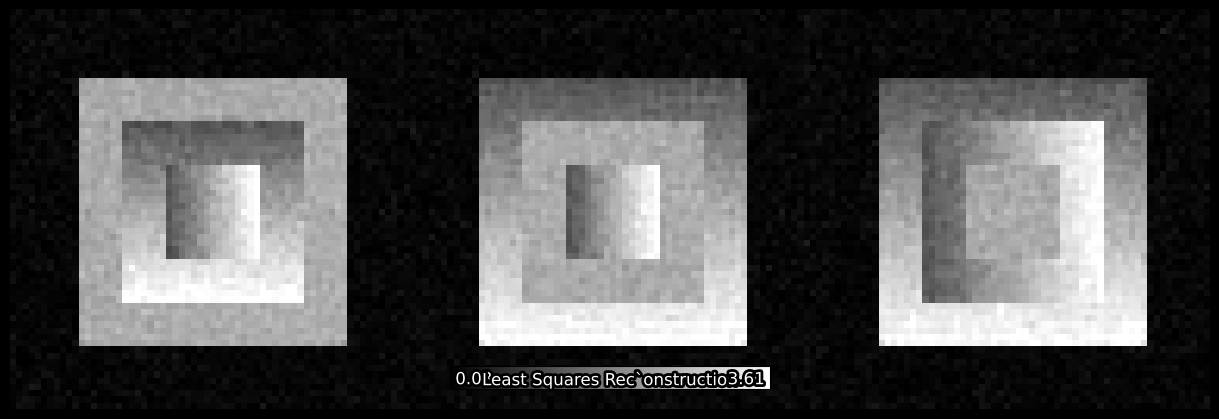

In [56]:
rlp.plot.planes(f'{prefix}-lsq.h5', title='Least Squares Rec`onstruction')

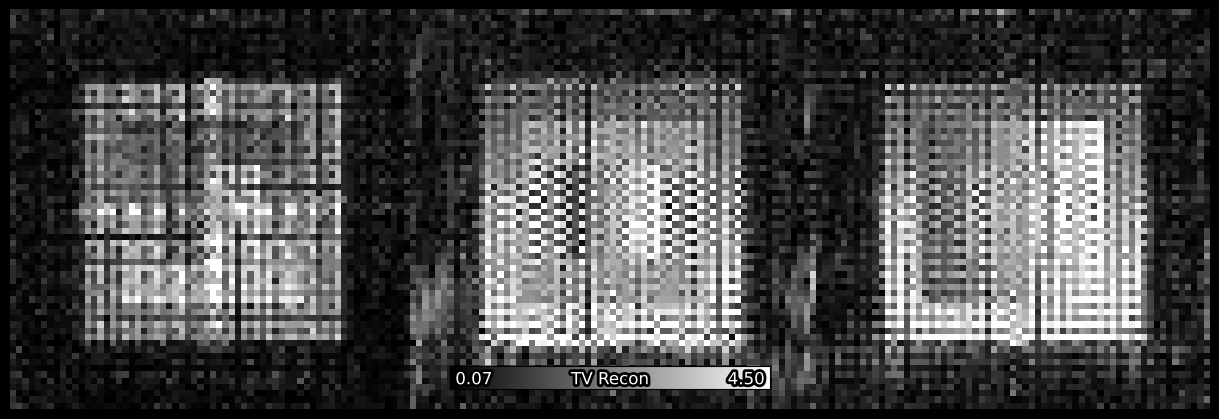

In [59]:
!riesling recon-rlsq --precon-p=1 --sense={prefix}-sim-sense.h5 {prefix}-kspace.h5 {prefix}-tv.h5 --scale=1 --tv=1e-2
rlp.plot.planes(f'{prefix}-tv.h5', title='TV Recon')

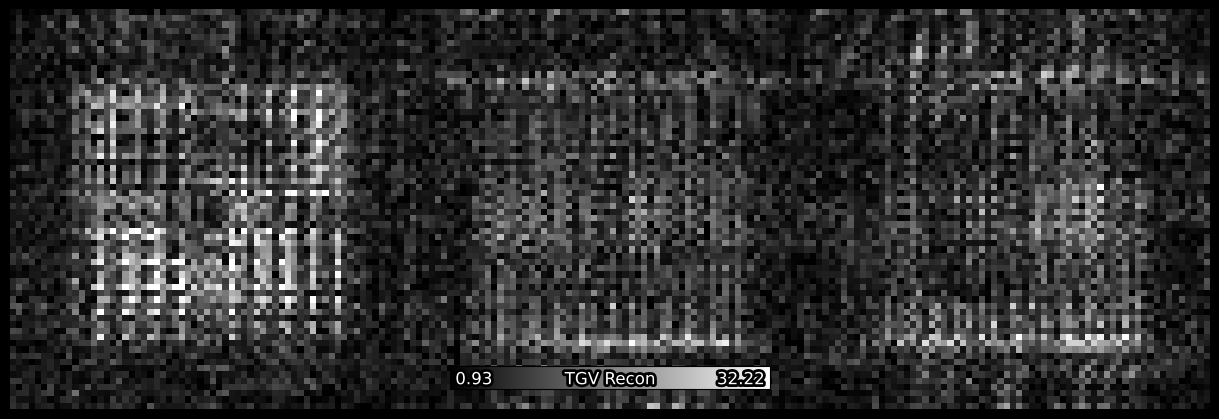

In [ ]:
#!riesling recon-rlsq --sense={prefix}-sim-sense.h5 {prefix}-kspace.h5 {prefix}-tgv.h5 --scale=1 --tgv=1e-2
rlp.plot.planes(f'{prefix}-tgv.h5', title='TGV Recon')

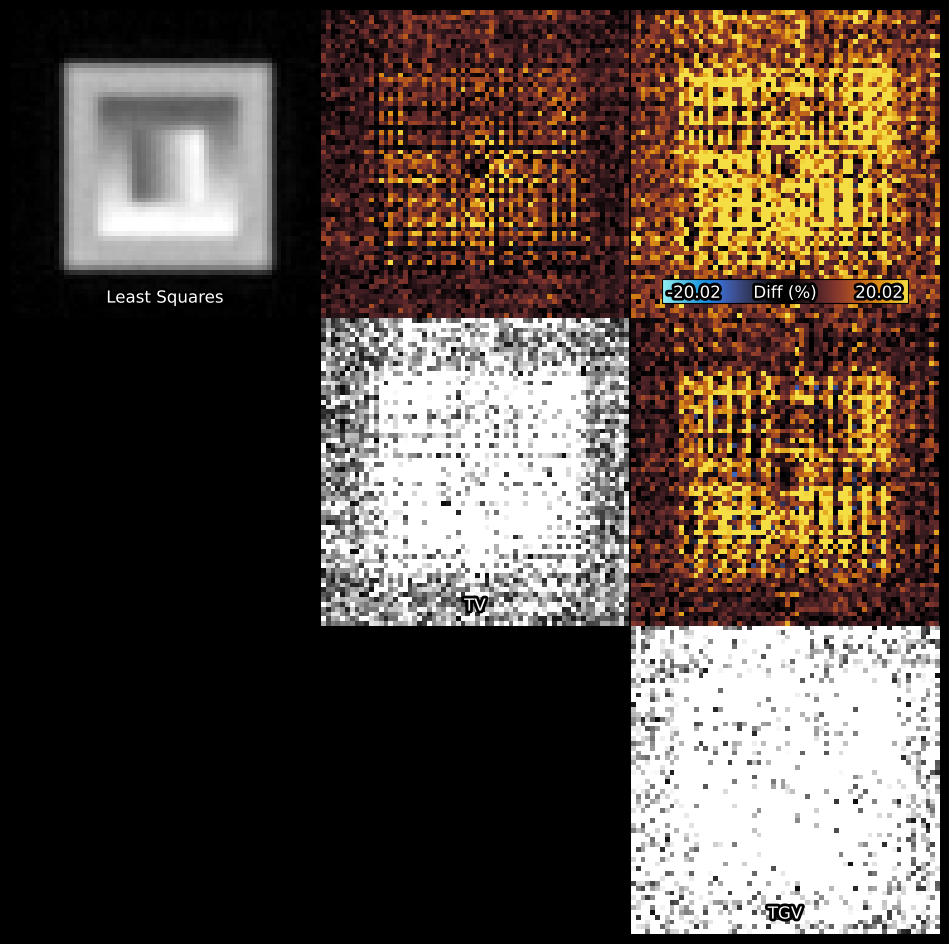

In [ ]:
rlp.plot.diff_matrix([f'{prefix}-lsq.h5',f'{prefix}-tv.h5',f'{prefix}-tgv.h5'], titles=['Least Squares', 'TV', 'TGV'], cbar=False)

In [ ]:
import h5py

def inspect_h5(fname):
    print("\nFILE:", fname)
    with h5py.File(fname, "r") as f:
        def visit(name, obj):
            print(name)
            if hasattr(obj, "shape"):
                print("  shape:", obj.shape)
                print("  dtype:", obj.dtype)
                print("  attrs:", dict(obj.attrs))
                print("  dims:", [obj.dims[i].label for i in range(len(obj.shape))])
        f.visititems(visit)

inspect_h5(f"{prefix}-sim-sense.h5")  # tutorial/example file


FILE: tut-sim-sense.h5
data
  shape: (4, 1, 64, 64, 64)
  dtype: complex64
  attrs: {'DIMENSION_LABELS': array(['channel', 'b', 'k', 'j', 'i'], dtype=object)}
  dims: ['channel', 'b', 'k', 'j', 'i']
